In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

First 5 rows of the dataset:
   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  \
0                  8              1          

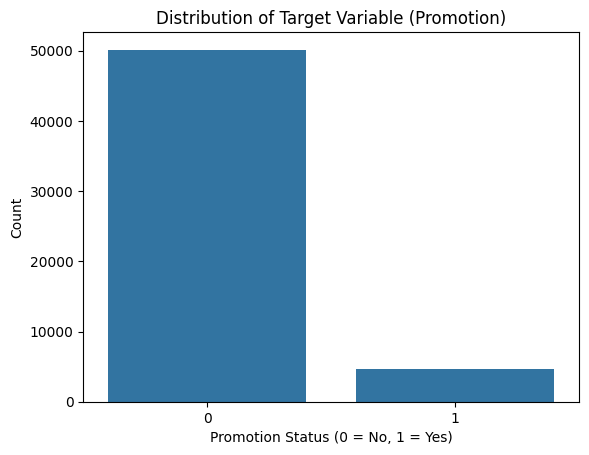

In [6]:

print("First 5 rows of the dataset:")
print(train.head())
print("\nDataset Info:")
print(train.info())
print("\nStatistical Summary:")
print(train.describe())
print("\nMissing Values:")
print(train.isnull().sum())
sns.countplot(x='is_promoted', data=train)
plt.title("Distribution of Target Variable (Promotion)")
plt.xlabel("Promotion Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [7]:
train = train.fillna(train.mean(numeric_only=True))
test = test.fillna(test.mean(numeric_only=True))

In [8]:
le = LabelEncoder()
for col in train.columns:
    if train[col].dtype == "object":
        train[col] = le.fit_transform(train[col].astype(str))
        test[col] = le.transform(test[col].astype(str))


In [12]:
target = 'is_promoted'
X = train.drop(columns=[target])
y = train[target]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_val)
acc1 = accuracy_score(y_val, pred1)
print("\nModel 1 Accuracy:", acc1)


Model 1 Accuracy: 0.9370552818828681


In [15]:
model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_val)
acc2 = accuracy_score(y_val, pred2)
print("Model 2 Accuracy:", acc2)

Model 2 Accuracy: 0.9291187739463601


In [16]:
best_model = model2 if acc2 > acc1 else model1

In [17]:
test_predictions = best_model.predict(test)

In [19]:
sample["is_promoted"] = test_predictions
sample.to_csv("final_submission.csv", index=False)
print("\nSubmission file created successfully!")


Submission file created successfully!


In [20]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(test)
sample["is_promoted"] = lr_pred
sample.to_csv("submission_lr.csv", index=False)
print("Logistic Regression submission ready!")

Logistic Regression submission ready!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(test)
sample["is_promoted"] = dt_pred
sample.to_csv("submission_dt.csv", index=False)
print("Decision Tree submission ready!")

Decision Tree submission ready!


In [25]:
from sklearn.ensemble import GradientBoostingClassifier


In [26]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [27]:
gb_pred_val = gb_model.predict(X_val)
gb_accuracy = accuracy_score(y_val, gb_pred_val)
print("\nGradient Boosting Accuracy:", gb_accuracy)


Gradient Boosting Accuracy: 0.9408866995073891


In [30]:
print(acc1)
print(acc2)

0.9370552818828681
0.9291187739463601


In [31]:
print(gb_accuracy)

0.9408866995073891


In [32]:
best_model = gb_model   # if GB gives highest accuracy

In [34]:
gb_test_pred = gb_model.predict(test)

In [35]:
sample["is_promoted"] = gb_test_pred
sample.to_csv("submission_gb.csv", index=False)
print("Gradient Boosting submission ready!")

Gradient Boosting submission ready!
